In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
!pip install -q flask joblib scikit-learn pandas numpy requests matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Classes:", iris.target_names)

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["target"].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset Shape: (150, 5)

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [7]:
pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=iris.target_names))

Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



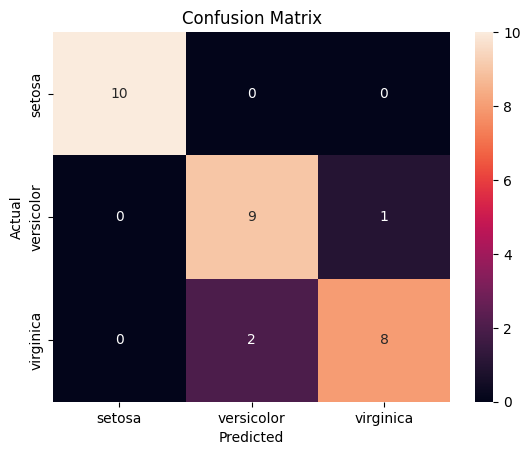

In [8]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
joblib.dump(model, "iris_model.joblib")

print("Model saved successfully")

Model saved successfully


In [10]:
loaded_model = joblib.load("iris_model.joblib")

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = loaded_model.predict(sample)[0]

print("Prediction:", prediction)
print("Species:", iris.target_names[prediction])

Prediction: 0
Species: setosa


In [11]:
app_code = '''
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load("iris_model.joblib")

@app.route("/")
def home():
    return jsonify({"message": "Iris ML API is running"})

@app.route("/health")
def health():
    return jsonify({"status": "healthy"})

@app.route("/api/predict", methods=["POST"])
def predict():
    data = request.get_json()

    features = np.array([[
        data["sepal_length"],
        data["sepal_width"],
        data["petal_length"],
        data["petal_width"]
    ]])

    prediction = model.predict(features)[0]

    species = ["setosa", "versicolor", "virginica"][prediction]

    return jsonify({
        "prediction": int(prediction),
        "species": species
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [12]:
import subprocess
import time

process = subprocess.Popen(
    ["python", "app.py"]
)

time.sleep(3)

print("Flask server started")

Flask server started


In [13]:
import requests

response = requests.get("http://127.0.0.1:5000/health")

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'status': 'healthy'}


In [14]:
data = {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

response = requests.post(
    "http://127.0.0.1:5000/api/predict",
    json=data
)

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'prediction': 0, 'species': 'setosa'}


In [15]:
data = {
    "sepal_length": 5.1
}

response = requests.post(
    "http://127.0.0.1:5000/api/predict",
    json=data
)

print("Status Code:", response.status_code)

Status Code: 500


In [17]:
!pip install -q pyngrok

In [19]:
from pyngrok import ngrok

ngrok.set_auth_token("3Ii5Wirnlh3Dq5SCvTLPgN0hJ8H_4hUWJWq277hYjcSkoZKRX")

print("ngrok authenticated successfully")

ngrok authenticated successfully


In [20]:
from pyngrok import ngrok

public_url = ngrok.connect(5000)

print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://aflame-unnamed-careless.ngrok-free.dev" -> "http://localhost:5000"


In [21]:
import requests

response = requests.get(public_url.public_url + "/")

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'message': 'Iris ML API is running'}


In [22]:
sample = {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

response = requests.post(
    "http://127.0.0.1:5000/api/predict",
    json=sample
)

print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'prediction': 0, 'species': 'setosa'}


In [23]:
public_url

<NgrokTunnel: "https://aflame-unnamed-careless.ngrok-free.dev" -> "http://localhost:5000">

In [24]:
response = requests.get(public_url.public_url + "/health")

print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'status': 'healthy'}


In [25]:
response = requests.post(
    public_url.public_url + "/api/predict",
    json=sample
)

print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'prediction': 0, 'species': 'setosa'}


In [26]:
print(public_url.public_url)

https://aflame-unnamed-careless.ngrok-free.dev


In [27]:
joblib.dump(model, "iris_model.joblib")

print("iris_model.joblib created")

iris_model.joblib created


In [28]:
import os

print("File exists:", os.path.exists("iris_model.joblib"))

File exists: True


In [29]:
%%writefile inference.py

import json
import joblib
import numpy as np

def model_fn(model_dir):
    model_path = f"{model_dir}/iris_model.joblib"
    model = joblib.load(model_path)
    return model

def input_fn(request_body, request_content_type):
    if request_content_type != "application/json":
        raise ValueError("Only application/json is supported")

    data = json.loads(request_body)

    if isinstance(data, dict):
        features = data["features"]
    else:
        features = data

    return np.array(features).reshape(1, -1)

def predict_fn(input_data, model):
    prediction = model.predict(input_data)
    probabilities = model.predict_proba(input_data)

    return {
        "prediction": int(prediction[0]),
        "probabilities": probabilities[0].tolist()
    }

def output_fn(prediction, accept):
    if accept != "application/json":
        raise ValueError("Only application/json is supported")

    return json.dumps(prediction), accept

Writing inference.py


In [30]:
import os

print("inference.py exists:", os.path.exists("inference.py"))

inference.py exists: True


In [31]:
import tarfile
import os

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("iris_model.joblib")

print("Created model.tar.gz")
print("File exists:", os.path.exists("model.tar.gz"))

Created model.tar.gz
File exists: True


In [32]:
with tarfile.open("model.tar.gz", "r:gz") as tar:
    print("Files inside model.tar.gz:")
    for member in tar.getnames():
        print(member)

Files inside model.tar.gz:
iris_model.joblib


In [33]:
import inference

model_test = inference.model_fn(".")

print("Model loaded successfully")

Model loaded successfully


In [34]:
request_body = '{"features": [5.1, 3.5, 1.4, 0.2]}'

input_data = inference.input_fn(
    request_body,
    "application/json"
)

print("Input data:", input_data)

Input data: [[5.1 3.5 1.4 0.2]]


In [35]:
prediction = inference.predict_fn(
    input_data,
    model_test
)

print("Prediction:", prediction)

Prediction: {'prediction': 0, 'probabilities': [1.0, 0.0, 0.0]}


In [36]:
result, content_type = inference.output_fn(
    prediction,
    "application/json"
)

print("Result:", result)
print("Content Type:", content_type)

Result: {"prediction": 0, "probabilities": [1.0, 0.0, 0.0]}
Content Type: application/json


In [37]:
result, content_type = inference.output_fn(
    prediction,
    "application/json"
)

print("Result:", result)
print("Content Type:", content_type)

Result: {"prediction": 0, "probabilities": [1.0, 0.0, 0.0]}
Content Type: application/json


In [38]:
!ls -lh

total 200K
-rw-r--r-- 1 root root  823 Sep 17 06:43 app.py
-rw-r--r-- 1 root root  948 Sep 17 06:52 inference.py
-rw-r--r-- 1 root root 164K Sep 17 06:52 iris_model.joblib
-rw-r--r-- 1 root root  19K Sep 17 06:52 model.tar.gz
drwxr-xr-x 2 root root 4.0K Sep 17 06:52 __pycache__
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data


In [39]:
from google.colab import files

files.download("app.py")
files.download("inference.py")
files.download("iris_model.joblib")
files.download("model.tar.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>